---
title: Inflation
author:
  - name: Binh Nguyen
    affiliations: Universite Paris Saclay
    email: yenbinhpy308@gmail.com
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [35]:
# Time array
t = np.linspace(0.001, 14, 10000)

# Original era functions
adot_inf = np.exp(50*(t - 0.05))
adot_rad = 0.5 * t**(-0.5)
adot_mat = (2/3) * t**(-1/3)
adot_de  = np.exp(0.1*(t - 13))

# Transition times
t1, t2, t3 = 0.1, 1, 10

# Scaling factors to match values at transitions
A_inf_end = np.exp(50*(t1 - 0.05))
A_rad_start = 0.5 * t1**(-0.5)
scale_rad = A_inf_end / A_rad_start

A_rad_end = scale_rad * 0.5 * t2**(-0.5)
A_mat_start = (2/3) * t2**(-1/3)
scale_mat = A_rad_end / A_mat_start

A_mat_end = scale_mat * (2/3) * t3**(-1/3)
A_de_start = np.exp(0.1*(t3 - 13))
scale_de = A_mat_end / A_de_start

# Smooth sigmoid switch
def S(t, t0, delta):
    return 1 / (1 + np.exp(-(t - t0)/delta))

# Smooth transitions widths
delta1, delta2, delta3 = 0.01, 0.1, 0.5

# Connected \dot a(t)
adot = (
    adot_inf * (1 - S(t, t1, delta1)) +
    scale_rad * adot_rad * (S(t, t1, delta1) - S(t, t2, delta2)) +
    scale_mat * adot_mat * (S(t, t2, delta2) - S(t, t3, delta3)) +
    scale_de * adot_de * S(t, t3, delta3)
)

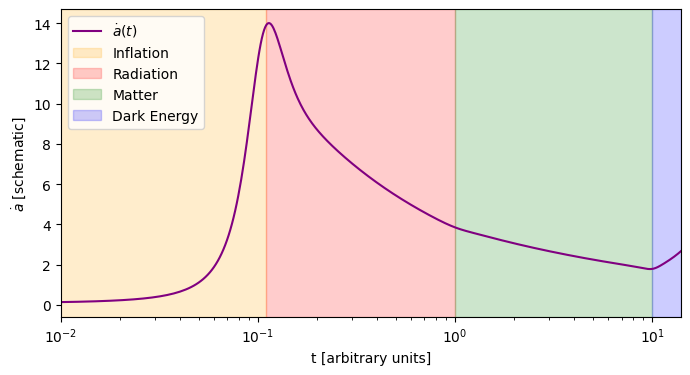

In [38]:
#| label: adot_sche
plt.figure(figsize=(8,4))
plt.plot(t, adot, color='purple', label=r'$\dot a(t)$')

# Colored era backgrounds
plt.axvspan(0.001, t1 + 0.01, color='orange', alpha=0.2, label='Inflation')
plt.axvspan(t1+0.01, t2, color='red', alpha=0.2, label='Radiation')
plt.axvspan(t2, t3, color='green', alpha=0.2, label='Matter')
plt.axvspan(t3, 14, color='blue', alpha=0.2, label='Dark Energy')

plt.xlabel('t [arbitrary units]')
plt.ylabel(r'$\dot a$ [schematic]')
plt.xscale("log")
plt.xlim(1e-2, 14)
plt.legend()
plt.show()

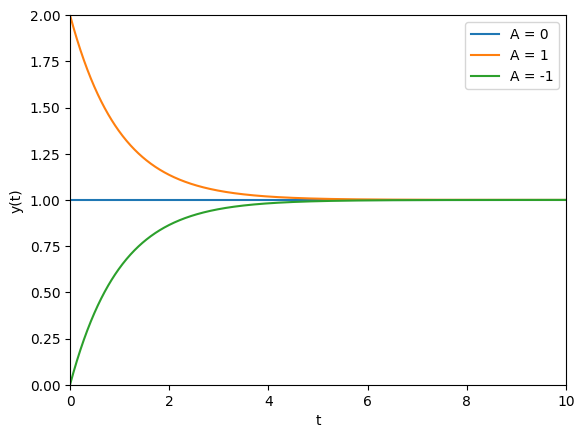

In [46]:
#| label: attractor_example

t = np.arange(0, 10, 0.01)
y = lambda A, t: 1 + A * np.exp(-t)
plt.figure()

plt.plot(t, y(0,t), label='A = 0')
plt.plot(t, y(1,t), label='A = 1')
plt.plot(t, y(-1,t), label='A = -1')

plt.xlim(0, 10)
plt.ylim(0, 2)
plt.xlabel('t')
plt.ylabel('y(t)')
plt.legend()
plt.show()

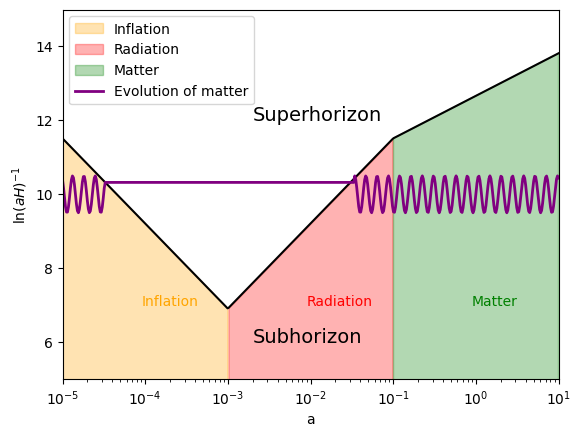

In [111]:
#| label: inflation_example

a_inf = 1e-3
a_r = 1e-1

a = np.logspace(-5, 1, 500)
h = np.zeros_like(a)

# region masks
mask_inf = a < a_inf
mask_rad = (a >= a_inf) & (a < a_r)
mask_mat = a >= a_r

# --- Main h(a) curve ---
h[mask_inf] = -np.log(a[mask_inf])  # inflation
h[mask_rad] = np.log(a[mask_rad]) - 2*np.log(a_inf)  # radiation
h[mask_mat] = 0.5*np.log(a[mask_mat]) + 0.5*np.log(a_r) - 2*np.log(a_inf)  # matter

plt.figure()

# colored regions
plt.fill_between(a[mask_inf], h[mask_inf], color="orange", alpha=0.3, label="Inflation")
plt.fill_between(a[mask_rad], h[mask_rad], color="red", alpha=0.3, label="Radiation")
plt.fill_between(a[mask_mat], h[mask_mat], color="green", alpha=0.3, label="Matter")

# main black curve
plt.plot(a, h, color="black")

plt.xscale("log")
plt.xlabel("a")
plt.ylabel("$\ln(aH)^{-1}$")

# --- Sinusoidal horizon line with flat sections ---
amp = 0.5           # sinusoid amplitude
freq = 20           # frequency

sin_val = amp * np.sin(freq * np.log(a)) + 10  # full sinusoid
h_line = sin_val.copy()

# find first and last index where h_line > h
mask = h_line > h
first_idx = np.where(mask)[0][0]
last_idx  = np.where(mask)[0][-1]

# set flat section
h_line[first_idx:last_idx] = h[first_idx]

# plot horizon line (thicker) labeled "Evolution"
plt.plot(a, h_line, color="purple", linewidth=2, label="Evolution of matter")

# --- Text labels ---
plt.text(0.9e-4, 7, "Inflation", color="orange")
plt.text(0.9e-2, 7, "Radiation", color="red")
plt.text(0.9e0, 7, "Matter", color="green")
plt.text(2e-3, 12, "Superhorizon", color="black", fontsize=14)
plt.text(2e-3, 6, "Subhorizon", color="black", fontsize=14)

plt.xlim(a[mask_inf][0], a[mask_mat][-1])
plt.ylim(5,15)
plt.legend()

plt.show()

In [125]:
from scipy.integrate import solve_ivp
import matplotlib.cm as cm

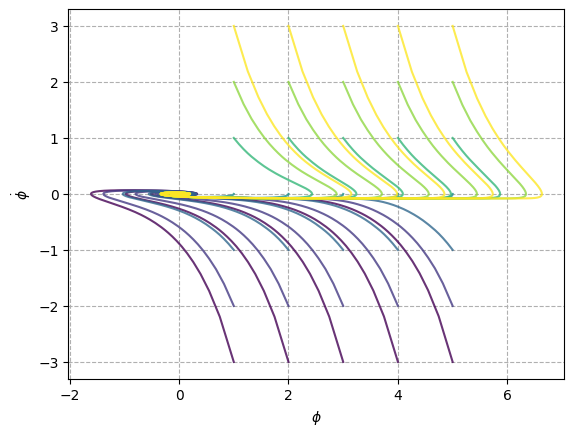

In [131]:
#| label: phase-space-family

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib.cm as cm

Mpl = 1.0
m = 0.1

def inflation_ode(t, Y):
    phi, phi_dot = Y
    H = np.sqrt((phi_dot**2 / 2 + m**2 * phi**2 / 2) / (3 * Mpl**2))
    return [phi_dot, -3*H*phi_dot - m**2 * phi]

t_span = (0, 200)
t_eval = np.linspace(*t_span, 2000)

phi0_vals = [1.0, 2.0, 3.0, 4.0, 5.0]
phi_dot0_vals = np.linspace(-3, 3, 7)

colors = cm.viridis(np.linspace(0, 1, len(phi_dot0_vals)))

plt.figure()

for i, phi_dot0 in enumerate(phi_dot0_vals):
    for phi0 in phi0_vals:
        sol = solve_ivp(inflation_ode, t_span, [phi0, phi_dot0], t_eval=t_eval)
        plt.plot(sol.y[0], sol.y[1], color=colors[i], alpha=0.8)

plt.xlabel(r"$\phi$")
plt.ylabel(r"$\dot{\phi}$")
plt.grid(linestyle="--")
plt.show()